# 03 — Tier 1 Feature Extraction (Composition-Only)

**Goal**: Extract physics-informed features from chemical formulas.

Features capture five aspects of ionic conductivity (σ = (σ₀/T) × exp(-Eₐ/kT)):
- **Carrier concentration** (σ₀): How much Li is available
- **Framework chemistry** (Eₐ): How tightly Li⁺ is bound at its site
- **Channel geometry** (Eₐ): How large the bottlenecks are
- **Anion polarizability** (Eₐ): How much the anion cushions Li⁺ during hops
- **Composition complexity**: Empirical patterns in good conductors

**Prerequisites**: Run notebooks 01 and 02 first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pymatgen.core import Composition, Element
import warnings
warnings.filterwarnings('ignore')

## Step 1: Define feature extraction

All features computed from known physical constants (Shannon ionic radii, Pauling 
electronegativity, experimental polarizabilities) combined with stoichiometry.

In [2]:
# Experimental anion polarizabilities in Å³
# Sources: Shannon & Fischer 2016, Tessman et al. 1953
ANION_POLARIZABILITY = {
    'O': 1.2,    # O²⁻
    'S': 5.5,    # S²⁻
    'Se': 7.0,   # Se²⁻
    'Te': 9.9,   # Te²⁻
    'F': 1.0,    # F⁻
    'Cl': 3.0,   # Cl⁻
    'Br': 4.2,   # Br⁻
    'I': 6.4,    # I⁻
    'N': 1.5,    # N³⁻ (approximate)
}

def identify_anions(comp):
    """Identify anion elements (most electronegative species that form the framework)."""
    anion_candidates = set(ANION_POLARIZABILITY.keys())
    anions = [el for el in comp.elements if el.symbol in anion_candidates]
    return anions if anions else [max(comp.elements, key=lambda e: e.X)]

def identify_cations(comp, anions):
    """Everything that isn't an anion."""
    anion_symbols = {a.symbol for a in anions}
    return [el for el in comp.elements if el.symbol not in anion_symbols]

def get_anion_type(anions):
    """Classify anion framework: oxide, sulfide, halide, or mixed."""
    symbols = {a.symbol for a in anions}
    halogens = {'F', 'Cl', 'Br', 'I'}
    types = []
    if 'O' in symbols: types.append('oxide')
    if 'S' in symbols: types.append('sulfide')
    if symbols & halogens: types.append('halide')
    if len(types) == 0: return 'other'
    if len(types) == 1: return types[0]
    return 'mixed'

def get_ionic_radius(element, default=1.0):
    """Get Shannon ionic radius for most common oxidation state."""
    try:
        for charge in element.common_oxidation_states:
            if charge in element.ionic_radii:
                return element.ionic_radii[charge]
        if element.ionic_radii:
            return list(element.ionic_radii.values())[0]
    except Exception:
        pass
    return default

def extract_composition_features(formula_string):
    """Extract Tier 1 features from a composition string."""
    try:
        comp = Composition(formula_string)
    except Exception:
        return None
    
    total_atoms = comp.num_atoms
    elements = comp.elements
    
    anions = identify_anions(comp)
    cations = identify_cations(comp, anions)
    
    # --- Carrier concentration (σ₀) ---
    li_count = comp['Li'] if Element('Li') in elements else 0
    
    # --- Framework chemistry (Eₐ — how tightly Li is bound) ---
    en_weighted = sum(comp[el] * el.X for el in elements) / total_atoms
    anion_en = max(a.X for a in anions) if anions else 0
    cation_en_weighted = (
        sum(comp[el] * el.X for el in cations) / sum(comp[el] for el in cations)
        if cations else 0
    )
    en_difference = anion_en - cation_en_weighted
    
    # --- Channel geometry (Eₐ — bottleneck size proxy) ---
    radii = {el: get_ionic_radius(el) for el in elements}
    mean_radius = sum(comp[el] * radii[el] for el in elements) / total_atoms
    anion_radius = max(radii[a] for a in anions) if anions else 0
    radius_std = np.std([radii[el] for el in elements for _ in range(int(comp[el]))])
    
    # --- Anion polarizability (Eₐ — barrier softening) ---
    # Weighted average polarizability of anion sublattice
    anion_total = sum(comp[a] for a in anions)
    anion_pol = (
        sum(comp[a] * ANION_POLARIZABILITY.get(a.symbol, 1.0) for a in anions) / anion_total
        if anion_total > 0 else 0
    )
    
    # --- Lattice dynamics proxy ---
    mean_mass = float(sum(comp[el] * el.atomic_mass for el in elements) / total_atoms)
    
    # --- Composition complexity ---
    n_elements = len(elements)
    mean_atomic_number = sum(comp[el] * el.Z for el in elements) / total_atoms
    anion_type = get_anion_type(anions)
    
    return {
        'li_count': li_count,
        'mean_electronegativity': en_weighted,
        'anion_electronegativity': anion_en,
        'cation_anion_en_diff': en_difference,
        'mean_ionic_radius': mean_radius,
        'anion_ionic_radius': anion_radius,
        'radius_std': radius_std,
        'anion_polarizability': anion_pol,
        'mean_atomic_mass': mean_mass,
        'n_elements': n_elements,
        'mean_atomic_number': mean_atomic_number,
        'anion_type': anion_type,
    }

## Step 2: Extract features and drop unparseable entries

In [3]:
def featurize_dataset(df, label):
    """Apply feature extraction, drop entries that fail to parse."""
    print(f"Extracting features for {label} ({len(df)} entries)...")
    
    features = []
    for _, row in df.iterrows():
        feat = extract_composition_features(row['composition'])
        features.append(feat if feat is not None else {})
    
    feat_df = pd.DataFrame(features)
    
    # Find failed parses
    failed_mask = feat_df['li_count'].isna() if 'li_count' in feat_df.columns else pd.Series([True]*len(feat_df))
    n_failed = failed_mask.sum()
    
    if n_failed > 0:
        print(f"  Dropping {n_failed} unparseable compositions")
        df = df[~failed_mask].reset_index(drop=True)
        feat_df = feat_df[~failed_mask].reset_index(drop=True)
    
    # One-hot encode anion_type
    if 'anion_type' in feat_df.columns:
        dummies = pd.get_dummies(feat_df['anion_type'], prefix='anion')
        feat_df = pd.concat([feat_df.drop('anion_type', axis=1), dummies], axis=1)
    
    print(f"  Result: {len(df)} entries, {len(feat_df.columns)} features")
    return df, feat_df

# Load datasets
comp_train = pd.read_csv('comp_train.csv')
comp_test = pd.read_csv('comp_test.csv')
struct_train = pd.read_csv('struct_train.csv')
struct_test = pd.read_csv('struct_test.csv')

# Extract features (returns cleaned df + features)
comp_train, comp_train_feat = featurize_dataset(comp_train, 'comp_train')
comp_test, comp_test_feat = featurize_dataset(comp_test, 'comp_test')
struct_train, struct_train_feat = featurize_dataset(struct_train, 'struct_train')
struct_test, struct_test_feat = featurize_dataset(struct_test, 'struct_test')

Extracting features for comp_train (861 entries)...
  Dropping 32 unparseable compositions
  Result: 829 entries, 16 features
Extracting features for comp_test (121 entries)...
  Dropping 1 unparseable compositions
  Result: 120 entries, 16 features
Extracting features for struct_train (339 entries)...
  Result: 339 entries, 16 features
Extracting features for struct_test (69 entries)...
  Dropping 1 unparseable compositions
  Result: 68 entries, 16 features


## Step 3: Inspect features

In [4]:
print("=== Feature columns ===")
print(comp_train_feat.columns.tolist())

print(f"\n=== comp_train stats ({len(comp_train)} entries) ===")
display(comp_train_feat.describe().round(3))

print(f"\n=== Anion type counts (train) ===")
anion_cols = [c for c in comp_train_feat.columns if c.startswith('anion_') and c != 'anion_polarizability']
for col in anion_cols:
    print(f"  {col}: {int(comp_train_feat[col].sum())} entries")

print(f"\n=== NaN check ===")
nans = comp_train_feat.isna().sum().sum()
print(f"Total NaN values: {nans}")

=== Feature columns ===
['li_count', 'mean_electronegativity', 'anion_electronegativity', 'cation_anion_en_diff', 'mean_ionic_radius', 'anion_ionic_radius', 'radius_std', 'anion_polarizability', 'mean_atomic_mass', 'n_elements', 'mean_atomic_number', 'anion_halide', 'anion_mixed', 'anion_other', 'anion_oxide', 'anion_sulfide']

=== comp_train stats (829 entries) ===


,li_count,mean_electronegativity,anion_electronegativity,cation_anion_en_diff,mean_ionic_radius,anion_ionic_radius,radius_std,anion_polarizability,mean_atomic_mass,n_elements,mean_atomic_number
count,829.000,829.000,829.000,829.000,829.000,829.000,826.000,829.000,829.000,829.000,829.000
mean,3.422,2.410,3.275,1.893,1.126,1.392,0.267,2.180,27.911,4.526,12.778
std,2.736,0.396,0.346,0.368,0.088,0.245,0.108,1.752,9.596,0.811,3.838
min,0.022,1.282,2.190,0.690,0.774,0.580,0.000,1.000,3.631,2.000,2.000
25%,1.200,2.112,3.160,1.677,1.070,1.260,0.184,1.200,21.418,4.000,10.355
50%,2.400,2.385,3.440,1.807,1.111,1.260,0.267,1.200,24.285,5.000,11.556
75%,6.000,2.832,3.440,2.220,1.148,1.670,0.317,1.800,35.806,5.000,15.846
max,17.000,2.961,3.980,3.000,1.609,2.070,0.580,6.400,94.951,6.000,39.500



=== Anion type counts (train) ===
  anion_electronegativity: 2715 entries
  anion_ionic_radius: 1153 entries
  anion_halide: 22 entries
  anion_mixed: 105 entries
  anion_other: 17 entries
  anion_oxide: 580 entries
  anion_sulfide: 105 entries

=== NaN check ===
Total NaN values: 3


## Step 4: Feature correlations with conductivity

Feature correlations with log(conductivity):
anion_electronegativity   -0.227
cation_anion_en_diff      -0.214
mean_electronegativity    -0.108
mean_atomic_mass           0.103
mean_atomic_number         0.121
radius_std                 0.153
anion_ionic_radius         0.192
li_count                   0.195
mean_ionic_radius          0.244
anion_polarizability       0.252
n_elements                 0.385
dtype: float64


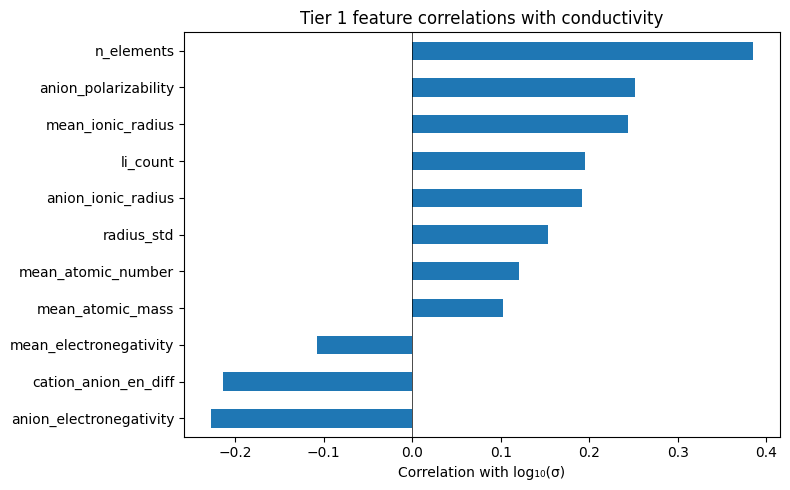

In [5]:
numeric_feat = comp_train_feat.select_dtypes(include=[np.number])
target = comp_train['log_conductivity']

correlations = numeric_feat.corrwith(target).sort_values()
print("Feature correlations with log(conductivity):")
print(correlations.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
correlations.plot(kind='barh', ax=ax)
ax.set_xlabel('Correlation with log₁₀(σ)')
ax.set_title('Tier 1 feature correlations with conductivity')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## Step 5: Save feature matrices

In [6]:
def save_featured(df_orig, df_feat, filename):
    out = pd.concat([
        df_orig[['id', 'composition', 'log_conductivity']].reset_index(drop=True),
        df_feat.reset_index(drop=True)
    ], axis=1)
    out.to_csv(filename, index=False)
    return out

save_featured(comp_train, comp_train_feat, 'comp_train_features.csv')
save_featured(comp_test, comp_test_feat, 'comp_test_features.csv')
save_featured(struct_train, struct_train_feat, 'struct_train_features.csv')
save_featured(struct_test, struct_test_feat, 'struct_test_features.csv')

print("Saved:")
print(f"  comp_train_features.csv    ({len(comp_train)} × {len(comp_train_feat.columns)} features)")
print(f"  comp_test_features.csv     ({len(comp_test)} × {len(comp_test_feat.columns)} features)")
print(f"  struct_train_features.csv  ({len(struct_train)} × {len(struct_train_feat.columns)} features)")
print(f"  struct_test_features.csv   ({len(struct_test)} × {len(struct_test_feat.columns)} features)")
print("\n✓ Tier 1 features done. Next: Tier 2 structural features or baseline model training.")

Saved:
  comp_train_features.csv    (829 × 16 features)
  comp_test_features.csv     (120 × 16 features)
  struct_train_features.csv  (339 × 16 features)
  struct_test_features.csv   (68 × 16 features)

✓ Tier 1 features done. Next: Tier 2 structural features or baseline model training.
